In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
main_data=[]
respective_user=[]
for u in range(1, 89):
    df=pd.read_excel(f"../../../Dataset/behaviour_biometrics_dataset/feature_kmt_dataset/feature_kmt_xlsx/feature_kmt_user_{u:04d}.xlsx")
    relevant=df[df["label"]==1]
    relevant=relevant[["dwell_avg","flight_avg","traj_avg"]]
    relevant=relevant.to_numpy()
    main_data.append(relevant)
    respective_user.extend([u]*len(relevant))
    

In [3]:
from sklearn.preprocessing import StandardScaler
train_stack=np.vstack(main_data[:60]) #train set
scaler=StandardScaler()
scaler.fit(train_stack) #finds mean and std
for i in range(len(main_data)):
    main_data[i]=scaler.transform(main_data[i]) #normalizes full data


In [4]:
dict_data={}
for i in range(88):
    dict_data[i]=main_data[i]

In [5]:
import torch
import torch.nn as nn

class Protonet(nn.Module):
    def __init__(self):
        super(Protonet, self).__init__()
        self.hlayer1=nn.Linear(3, 128)
        self.bn1=nn.BatchNorm1d(128)
        self.relu1=nn.ReLU()
        self.do1=nn.Dropout(0.2)
        self.hlayer2=nn.Linear(128,128)
        self.bn2=nn.BatchNorm1d(128)
        self.relu2=nn.ReLU()
        self.do2=nn.Dropout(0.2)
        self.fc=nn.Linear(128, 64)

    def forward(self, x):
        x=self.fc(self.do2(self.relu2(self.bn2(self.hlayer2(self.do1(self.relu1(self.bn1(self.hlayer1(x)))))))))
        return x


In [6]:
def dist_calc(x,y):
    n=x.size(0)
    m=y.size(0)
    d=x.size(1)
    x=x.unsqueeze(1).expand(n, m, d)
    y=y.unsqueeze(0).expand(n, m, d)
    dist=torch.pow(x-y, 2).sum(2)
    return dist


In [7]:
def episode(y_labels, dict):
    random_users=np.random.choice(y_labels, 5, replace=False)
    support_set=[]
    query_set=[]
    for u in random_users:
        user=dict_data[u]
        indices=np.random.choice(len(user), 10, replace=False)
        selected_data=user[indices]
        support_set.append(selected_data[:5])
        query_set.append(selected_data[5:])

    x_support=torch.FloatTensor(np.array(support_set))
    x_query=torch.FloatTensor(np.array(query_set))
    return x_support, x_query

    

        

In [8]:
import torch.optim as opt
import torch.nn.functional as F

In [9]:
model=Protonet()
optimizer=opt.AdamW(model.parameters(), lr=0.001)

In [10]:
model.train()
train_ids=list(range(60))
for e in range(3000):
    x_support, x_query=episode(train_ids, dict_data)
    emb_sup=model(x_support.view(-1, 3)) #makes initial 3d into flattended 2d 25,3 and sends to model
    emb_qur=model(x_query.view(-1,3))
    prototypes=emb_sup.view(5,5,64).mean(1) #unflattens back to 5,5,64 and takes mean per user to we get 5,64
    dists=dist_calc(emb_qur, prototypes)
    target_inds=torch.arange(0, 5).view(5, 1, 1).expand(5, 5, 1).long() #real 
    target_inds=target_inds.reshape(-1)
    log_p_y=F.log_softmax(-dists, dim=1) #distance to probability and - cuz big dist means lower prob 
    loss=F.nll_loss(log_p_y, target_inds) #gets loss comparin the softmax ad real
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"Episode{e+1}  Loss={loss.item():.4f}")





Episode1  Loss=0.9843
Episode2  Loss=0.1411
Episode3  Loss=0.7216
Episode4  Loss=0.8257
Episode5  Loss=1.0271
Episode6  Loss=1.5826
Episode7  Loss=1.0466
Episode8  Loss=2.0965
Episode9  Loss=1.6781
Episode10  Loss=1.0562
Episode11  Loss=0.8639
Episode12  Loss=0.5112
Episode13  Loss=0.9007
Episode14  Loss=1.6809
Episode15  Loss=0.8330
Episode16  Loss=2.2318
Episode17  Loss=0.8992
Episode18  Loss=1.3481
Episode19  Loss=1.8129
Episode20  Loss=0.4568
Episode21  Loss=1.4903
Episode22  Loss=0.6210
Episode23  Loss=0.8389
Episode24  Loss=1.0279
Episode25  Loss=0.8144
Episode26  Loss=0.6943
Episode27  Loss=0.2742
Episode28  Loss=1.2988
Episode29  Loss=0.6384
Episode30  Loss=0.7176
Episode31  Loss=0.7311
Episode32  Loss=0.4590
Episode33  Loss=0.6880
Episode34  Loss=0.2767
Episode35  Loss=0.4093
Episode36  Loss=0.4911
Episode37  Loss=0.9605
Episode38  Loss=1.2177
Episode39  Loss=1.2667
Episode40  Loss=0.5607
Episode41  Loss=0.8464
Episode42  Loss=0.6937
Episode43  Loss=0.4138
Episode44  Loss=0.54

In [11]:
def validation(model, user_ids_list, dict_data):
    model.eval()
    y_true=[] 
    y_scores=[]
    with torch.no_grad():
        for n in range(3000):
            user_id=np.random.choice(user_ids_list)
            user_data=dict_data[user_id]
            indices=np.random.choice(10, 6, replace=False)
            support_data=user_data[indices[:5]]
            crct_query_data=user_data[indices[5]].reshape(1, 3)
            support_tensor=torch.FloatTensor(support_data)
            crct_query_tensor=torch.FloatTensor(crct_query_data)
            support_emb=model(support_tensor)
            prototype=support_emb.mean(0).unsqueeze(0) 
            crct_query_emb=model(crct_query_tensor)
            crct_dist=torch.pow(prototype-crct_query_emb, 2).sum(1).item()
            y_true.append(1)
            y_scores.append(-crct_dist) 
            
            impostor_id=np.random.choice(user_ids_list)
            while impostor_id==user_id:
                impostor_id=np.random.choice(user_ids_list)
            imp_data=dict_data[impostor_id]
            imp_idx=np.random.choice(len(imp_data))
            imp_query_data=imp_data[imp_idx].reshape(1, 3)
            imp_query_tensor=torch.FloatTensor(imp_query_data)
            imp_query_emb=model(imp_query_tensor)
            dist_imp=torch.pow(prototype-imp_query_emb, 2).sum(1).item()
            y_true.append(0)
            y_scores.append(-dist_imp)
            
    ####
    fpr, tpr, thresholds=roc_curve(y_true, y_scores)
    fnr=1-tpr
    eer_index=np.nanargmin(np.absolute(fnr-fpr))
    
    eer=fpr[eer_index]
    val_threshold=thresholds[eer_index] 
    ####
    return val_threshold

In [12]:
remaining_users=list(range(60, 88))
np.random.seed(42) 
np.random.shuffle(remaining_users)
val_users=remaining_users[:14]
test_users=remaining_users[14:]


In [13]:
from sklearn.metrics import roc_curve

import random
from sklearn.metrics import accuracy_score, f1_score
accuracies=[]
def testing(model, test_user_ids, dict_data, threshold):
    model.eval()
    for uid in test_user_ids:
        user_data=dict_data[uid]
        indices=np.random.choice(len(user_data), 10, replace=False)
        support=user_data[indices[:5]]
        crct_queries=user_data[indices[5:]]
        imp_queries=[]
        for u in range(5):
            imp_id=np.random.choice(list(dict_data.keys()))
            while imp_id==uid:
                imp_id=np.random.choice(list(dict_data.keys()))
            other_data=dict_data[imp_id]
            random_row=other_data[np.random.choice(len(other_data))]
            imp_queries.append(random_row)
        imp_queries_np=np.array(imp_queries)
        mixed_queries=np.concatenate([crct_queries, imp_queries_np])
        mixed_labels=[1]*5+ [0]*5 
##
        shuffle_indices =np.arange(10)
        np.random.shuffle(shuffle_indices)
        final_query_np = mixed_queries[shuffle_indices]
        final_labels = np.array(mixed_labels)[shuffle_indices]
##
        with torch.no_grad():
            support_emb=model(torch.FloatTensor(support))
            prototype=support_emb.mean(0).unsqueeze(0)
            query_emb=model(torch.FloatTensor(final_query_np))
            dists=torch.pow(prototype-query_emb, 2).sum(1)
            pred_labels=[]
            for d in dists:
                if d.item()<threshold:
                    pred_labels.append(1) 
                else:
                    pred_labels.append(0) 
            acc=accuracy_score(final_labels, pred_labels)
            fm = f1_score(final_labels, pred_labels, zero_division=0)
            print(f"User {uid} Accuracy: {acc:.2f} F1-Score: {fm:.2f}")
            accuracies.append(acc)
val_thresh=-validation(model, val_users, dict_data)
testing(model, test_users, dict_data, val_thresh)
net_acc=np.mean(accuracies)
print(f"TOTAL ACC={net_acc}")

User 62 Accuracy: 0.90 F1-Score: 0.89
User 76 Accuracy: 0.70 F1-Score: 0.67
User 83 Accuracy: 1.00 F1-Score: 1.00
User 63 Accuracy: 0.80 F1-Score: 0.80
User 86 Accuracy: 0.90 F1-Score: 0.89
User 84 Accuracy: 0.90 F1-Score: 0.91
User 78 Accuracy: 0.90 F1-Score: 0.89
User 87 Accuracy: 1.00 F1-Score: 1.00
User 80 Accuracy: 0.80 F1-Score: 0.80
User 67 Accuracy: 0.80 F1-Score: 0.80
User 70 Accuracy: 0.70 F1-Score: 0.67
User 74 Accuracy: 0.90 F1-Score: 0.91
User 79 Accuracy: 1.00 F1-Score: 1.00
User 66 Accuracy: 0.90 F1-Score: 0.89
TOTAL ACC=0.8714285714285716


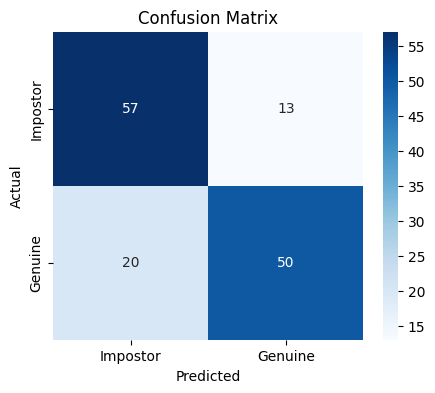

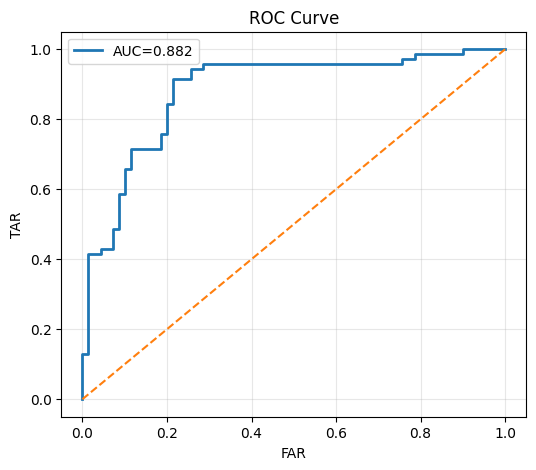

In [18]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
y_true = []
y_pred = []
y_scores = []

model.eval()
for uid in test_users:
    user_data = dict_data[uid]
    idx = np.random.choice(len(user_data), 10, replace=False)

    support = user_data[idx[:5]]
    genuine = user_data[idx[5:]]

    impostors = []
    for _ in range(5):
        imp_id = random.choice(list(dict_data.keys()))
        while imp_id == uid:
            imp_id = random.choice(list(dict_data.keys()))
        impostors.append(dict_data[imp_id][np.random.choice(len(dict_data[imp_id]))])

    queries = np.concatenate([genuine, np.array(impostors)])
    labels = np.array([1]*5 + [0]*5)

    perm = np.random.permutation(10)
    queries = queries[perm]
    labels = labels[perm]

    with torch.no_grad():
        proto = model(torch.FloatTensor(support)).mean(0, keepdim=True)
        emb = model(torch.FloatTensor(queries))
        dists = ((proto - emb)**2).sum(1)

    for d, l in zip(dists, labels):
        y_true.append(l)
        y_pred.append(1 if d.item() < val_thresh else 0)
        y_scores.append(-d.item())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Impostor', 'Genuine'],
    yticklabels=['Impostor', 'Genuine']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f'AUC={roc_auc:.3f}')
plt.plot([0,1], [0,1], '--')
plt.xlabel('FAR')
plt.ylabel('TAR')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
